# Tutorial: Access Proba-2 Science Archive data via python

```
Author: ESDC Team at ESAC
Date Last Modified: 15/07/2026
```

This notebook illustrateshow to access Proba-2 Science Archive (P2SA) data using the Table Access Protocol (TAP) and the Astronomical Query Language (ADQL) in python. See [here](http://p2sa.esac.esa.int/p2sa/#aio) for more information on the P2SA TAP service. We use [astroquery](https://astroquery.readthedocs.io/en/latest/index.html) for the access via python.

## Table of Contents

- [1. Basic Use](#1-basic-use)
  - [1.2. Getting table data: Synchronous query](#12-getting-table-data-synchronous-query)
  - [1.3. Asynchronous query](#13-asynchronous-query)
  - [1.4. Asynchronous job removal](#14-asynchronous-job-removal)
- [2. P2SA Use Cases](#2-p2sa-use-cases)
  - [2.1 Quering P2SA Metadata](#21-quering-p2sa-metadata)
  - [2.2 Download P2SA data](#22-download-p2sa-data)
    - [2.3.1 Download Postcards](#231-download-postcards)
    - [2.3.2 Display Carrington movie](#232-display-carrington-movie)
    - [2.3.3 Download P2SA product](#233-download-p2sa-product)



## Requirements

The following python packages are required:

In [72]:
# python -m pip install astroquery numpy IPython 

In [73]:
from astroquery.utils.tap.core import TapPlus
from IPython.display import Image, Video
import numpy as np

## 1. Basic Use

We access the P2SA archive using the TAP+ protocol. TAP+ offers all funcationality that TAP does, but also allows users to log in to remote servers and have persistent user sessions. We do not make use of this functionality here, and instead use the anynomous user for all our requests. This means that our query results are stored temporarily on the ESDC servers and are then remove automatically.

To connect via TAP, we need the service's TAP URL. We find this on the [P2SA documentation](https://p2sa.esac.esa.int/p2sa/#aio).

### 1.1 Getting table metadata

First, we want to see which tables are accessible to use. We load the names of all public tables. Note that we are making **metadata** queries here, we are not yet retrieving the data itself.

In [74]:
p2sa = TapPlus(url='https://p2sa.esac.esa.int/p2sa-sl-tap/tap')  # we got this URL from the P2SA documentation
tables = p2sa.load_tables()

for table in tables:
    print(table.get_qualified_name())

INFO: Retrieving tables... [astroquery.utils.tap.core]
INFO: Parsing tables... [astroquery.utils.tap.core]
INFO: Done. [astroquery.utils.tap.core]
p2sa.file
p2sa.full_disk_solar_image
p2sa.instrument
p2sa.lyra_observation
p2sa.observation
p2sa.observatory
p2sa.science_object
p2sa.swap_observation
p2sa.v_carrington_rotation_file
p2sa.v_file
p2sa.v_lyra_observation
p2sa.v_observation
p2sa.v_swap_observation
public.dual
tap_config.coord_sys
tap_config.properties
tap_schema.columns
tap_schema.key_columns
tap_schema.keys
tap_schema.schemas
tap_schema.tables


The relevant tables for us have a `p2sa` prefix. Next, we load a table and inspect the column names.

In [75]:
table = p2sa.load_table('p2sa.observation')
print('TAP Table name:', table.get_qualified_name())

columns_observation = [column.name for column in table.columns]
print(columns_observation)


TAP Table name: p2sa.observation
['begin_date', 'calibrated', 'end_date', 'file_format', 'file_name', 'file_path', 'file_size', 'instrument_oid', 'observation_oid', 'observation_type', 'processing_level', 'science_objective', 'science_object_oid', 'wavelength_range']


This table contains metadata of Proba-2 observations, including start and end dates, calibration levels, filenames, and instrument IDs. In the P2Sa, there is also a `v_observation` table. To see how it differs, we retrieve the table and compare the columns between the two tables.

In [77]:
table = p2sa.load_table('p2sa.v_observation')
print('TAP Table name:', table.get_qualified_name())

columns_v_observation = [column.name for column in table.columns]
print(columns_v_observation)

difference = set(columns_v_observation) - set(columns_observation)
print("Columns in p2sa.v_observation but not in p2sa.observation:", difference)

TAP Table name: p2sa.v_observation
['begin_date', 'calibrated', 'end_date', 'file_format', 'file_name', 'file_path', 'file_size', 'instrument_name', 'observation_oid', 'observation_type', 'observatory_name', 'processing_level', 'science_objective', 'science_object_name', 'science_object_oid', 'wavelength_range']
Columns in p2sa.v_observation but not in p2sa.observation: {'observatory_name', 'science_object_name', 'instrument_name'}


`v_observation` is slightly more human-readable than `observation`, as it contains the instrument, observatory, and science object names as well as their numeric IDs.

### 1.2. Getting table data: Synchronous query

To get the actual content of these tables, we use the `launch_job`. We can run ADQL queries both synchronously and asynchronously. Synchronous queries are good for small queries that execute fast. The output is limited to 2000 rows.

We query the first 100 rows of the `p2sa.observation` table. We request all columns (`*`).

In [ ]:
job = p2sa.launch_job("select top 100 * from p2sa.observation")
print(job)


<Table length=100>
       name        dtype 
------------------ ------
        begin_date object
        calibrated   bool
          end_date object
       file_format  str20
         file_name object
         file_path  str80
         file_size  int64
    instrument_oid  int32
   observation_oid  int32
  observation_type object
  processing_level str200
 science_objective object
science_object_oid  int32
  wavelength_range object
Jobid: None
Phase: COMPLETED
Owner: None
Output file: 1784107633032OPER-result.vot
Results: None


`launch_job` returns a `job` that, when printed, shows us that we received the expected 100 entries in the table and the expected columns. The job has completed and the results are stored in memory - meaning that they are lost once our python session ends. To store them to file, we use the following call.

In [79]:
job = p2sa.launch_job("select top 100 * from p2sa.observation", dump_to_file=True, output_file="p2sa_observation_results.vot.gz")
print(job)

Jobid: None
Phase: COMPLETED
Owner: None
Output file: p2sa_observation_results.vot.gz
Results: None


To inspect the contents of the returned table, we use `get_results`.

In [80]:
result = job.get_results()
print(result)

print(result['file_name'].tolist())


       begin_date       calibrated ... science_object_oid wavelength_range
----------------------- ---------- ... ------------------ ----------------
2010-08-24T04:37:44.714      False ...                  1              174
2010-08-24T05:53:44.779      False ...                  1              174
2010-12-19T13:28:42.835      False ...                  1              174
2010-12-19T11:25:21.736      False ...                  1              174
2010-12-19T09:25:15.588      False ...                  1              174
2010-12-19T06:47:32.513      False ...                  1              174
2010-12-19T05:21:01.389      False ...                  1              174
2010-12-19T03:38:15.361      False ...                  1              174
2010-12-19T02:08:29.235      False ...                  1              174
2010-12-19T01:13:14.191      False ...                  1              174
                    ...        ... ...                ...              ...
2010-08-24T10:09:00.005  

### 1.3. Asynchronous query

Asynchronous TAP queries run as background jobs on the server. After submission, a job identifier is returned that can be used to check the query status and download the results when ready. This mode is better suited than synchronous execution for large or complex queries because it is not limited by HTTP timeouts and can handle longer processing times.

We request the first 5000 rows of the `p2sa.observation` table. Note that this is not possible with synchronous queries, as they are limited to 2000 rows.

In [81]:
job = p2sa.launch_job_async("select top 5000 * from p2sa.observation")
print(job)


INFO: Query finished. [astroquery.utils.tap.core]
<Table length=5000>
       name        dtype 
------------------ ------
        begin_date object
        calibrated   bool
          end_date object
       file_format  str20
         file_name object
         file_path  str80
         file_size  int64
    instrument_oid  int32
   observation_oid  int32
  observation_type object
  processing_level str200
 science_objective object
science_object_oid  int32
  wavelength_range object
Jobid: 1784107946873OPER
Phase: COMPLETED
Owner: None
Output file: async_20260715093226.vot
Results: None


This query is quite easy and finishes fast. More complicated queries (see below) will take longer to execute. In this case, `job.get_results` will wait for the server-side execution to finish before returning the results.

### 1.4. Asynchronous job removal

Each job has an associated `job.jobid`. It can be used to remove asynchronous jobs from the server.

In [82]:
p2sa.remove_jobs([job.jobid])

INFO: Removed jobs: '['1784107946873OPER']'. [astroquery.utils.tap.core]


## 2. P2SA Use Cases

After this more general introduction, we now address specific use cases and data access for the P2SA via TAP+. The AQDL syntax will become a bit more advanced. For a thorough introduction to ADQL, see the [IOVA documentation](https://www.ivoa.net/documents/ADQL/20180112/PR-ADQL-2.1-20180112.html).

### 2.1 Quering P2SA Metadata

We start by searching for all SWAP and LYRA observations made between two dates, June 6 and June 8 of 2015. We define these search parameters and then build the ADQUL query. We use an asynchronous query and inspect the results.

In [95]:
instrument_list = ["SWAP", "LYRA"]
date_start = "2015-05-06 00:00:00"
date_end = "2015-05-08 00:00:00"

instrument_filter = ", ".join(f"'{inst}'" for inst in instrument_list)
query = f"SELECT begin_date, instrument_name, observation_oid, calibrated FROM p2sa.v_observation WHERE instrument_name IN ({instrument_filter}) AND begin_date >= '{date_start}' AND end_date <= '{date_end}'"

job = p2sa.launch_job_async(query)
job.results = job.get_results()
print(job.results)

INFO: Query finished. [astroquery.utils.tap.core]
       begin_date       instrument_name observation_oid calibrated
----------------------- --------------- --------------- ----------
2015-05-06T00:01:00.449            SWAP       200975314       True
2015-05-06T00:01:00.449            SWAP       200976142      False
2015-05-06T00:03:00.503            SWAP       200975325       True
2015-05-06T00:03:00.503            SWAP       200976163      False
2015-05-06T00:05:00.504            SWAP       200973094       True
2015-05-06T00:05:00.504            SWAP       200976146      False
2015-05-06T00:07:00.455            SWAP       200973089       True
2015-05-06T00:07:00.455            SWAP       200976145      False
2015-05-06T00:09:00.457            SWAP       200973096       True
2015-05-06T00:09:00.457            SWAP       200976157      False
                    ...             ...             ...        ...
2015-05-07T23:59:03.417            SWAP       200971255      False
  2015-05-07

### 2.2 Download P2SA data

#### 2.3.1 Download Postcards

We now download a low-resolution jpg representation (a "postcard") of an observation. This will be our first actual data access.

To download data, we have to set the `data_context="data"` when instantiating the `TapPlus` service with the TAP URL.
For the postcard request itself, the following parameters are required:

1. `RETRIEVAL_TYPE='PRODUCT'` tells the service that you want to retrieve a data product.
2. `observation_oid` identifies the observation whose postcard should be downloaded. We take one from the metadata query above.
3. `PRODUCT_TYPE='POSTCARD'` tells the service that the product you want is the postcard image.

Step by step, the code does the following:

1. It creates a connection to the P2SA data service.
2. It prepares the required request parameters.
3. It downloads the postcard into a local JPG file.
4. It displays that downloaded file in the notebook using `Image`.


Retrieving data.
Data request: RETRIEVAL_TYPE=PRODUCT&observation_oid=200975314&PRODUCT_TYPE=POSTCARD
------>https
host = p2sa.esac.esa.int:443
context = /p2sa-sl-tap/data
Content-type = application/x-www-form-urlencoded
200 
Reading...
Done.


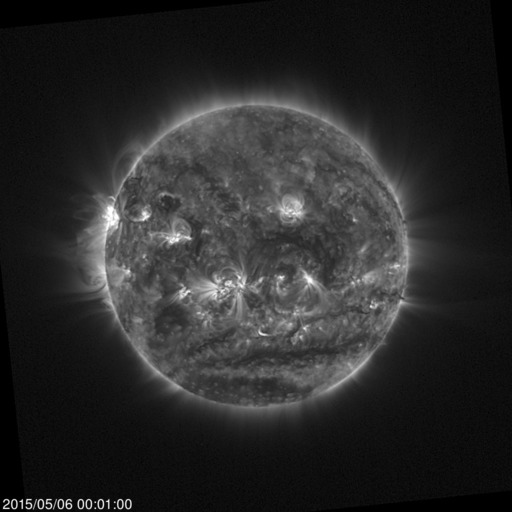

In [ ]:
p2sa_data = TapPlus(url='https://p2sa.esac.esa.int/p2sa-sl-tap/', data_context='data')

postcard_params = {
    'RETRIEVAL_TYPE': 'PRODUCT',
    'observation_oid': '200975314',
    'PRODUCT_TYPE': 'POSTCARD',
}

postcard_filename = 'postcard_200975314_astroquery.jpg'
p2sa_data.load_data(
    params_dict=postcard_params,
    output_file=postcard_filename,
    verbose=True,
)

Image(filename=postcard_filename)


#### 2.3.2 Display Carrington movie

Information on Carrington movies is stored in the `p2sa.v_carrington_rotation_file` table. In this example, we query the top row of this table, extract the `file_oid`, and then use the `Video` functionality of `ipython` to download and display the movie in the notebook.

In [93]:
p2sa = TapPlus(url='https://p2sa.esac.esa.int/p2sa-sl-tap/tap')

# Example: retrieve one Carrington movie file identifier.,
# You can adapt this query to your own date range or file type.,
query = """
SELECT TOP 1 file_oid
FROM p2sa.v_carrington_rotation_file
WHERE file_type = 'CR_YELLOW'
ORDER BY start_date DESC
"""

job = p2sa.launch_job(query=query)
results = job.get_results()

file_oid = str(results['file_oid'][0])
video_url = f'https://p2sa.esac.esa.int/p2sa-sl-tap/video?file_oid={file_oid}&data_retrieval_origin=UI'

print('Selected file_oid:', file_oid)
print('Video URL:', video_url)

Video(video_url, embed=False)

Selected file_oid: 162042
Video URL: https://p2sa.esac.esa.int/p2sa-sl-tap/video?file_oid=162042&data_retrieval_origin=UI


#### 2.3.3 Download P2SA product

To download specific file products to file by using their `file_oid`, we can use the `p2sa.file` table and a data query.

In [100]:
# File IDs to download
file_oids = [6605, 6606]
file_oid_csv = ",".join(str(x) for x in file_oids)

# 1) TAP query: inspect metadata for the selected products
p2sa = TapPlus(url="https://p2sa.esac.esa.int/p2sa-sl-tap/tap")

metadata_query = f"""
SELECT file_oid, file_name, file_size
FROM p2sa.file
WHERE file_oid IN ({file_oid_csv})
ORDER BY file_oid
"""

job = p2sa.launch_job(query=metadata_query)
metadata_table = job.get_results()
print(metadata_table)

# 2) Data request: download products as a tar file
p2sa_data = TapPlus(
    url="https://p2sa.esac.esa.int/p2sa-sl-tap/data",
    data_context="data",
)

download_params = {
    "retrieval_type": "PRODUCT",
    "QUERY": f"SELECT file_oid, file_name, file_path FROM p2sa.file where file_oid in ({file_oid_csv})",
    "data_retrieval_origin": "UI",
}

p2sa_data.load_data(params_dict=download_params, output_file='requested_files.tar', verbose=True)
print("Downloaded: requested_files.tar")

file_oid               file_name                file_size
-------- -------------------------------------- ---------
    6605 density_O_N2_2010-11-29_10-59_dawn.txt     22279
    6606 density_O_N2_2010-11-29_11-24_dusk.txt     17179
Retrieving data.
Data request: retrieval_type=PRODUCT&QUERY=SELECT+file_oid%2C+file_name%2C+file_path+FROM+p2sa.file+where+file_oid+in+%286605%2C6606%29&data_retrieval_origin=UI
------>https
host = p2sa.esac.esa.int:443
context = /p2sa-sl-tap/data
Content-type = application/x-www-form-urlencoded
200 
Reading...
Done.
Downloaded: requested_files.tar
